In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot 
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_toy.csv', usecols=['Age', 'Fare','Survived'])
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [3]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [4]:
# Train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size=0.3, random_state=0) 
X_train.shape, X_test.shape

((623, 2), (268, 2))

In [5]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [6]:
X_train.tail()

,Age,Fare,Age_imputed
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,NaN
559,36.0,17.4000,36.0
684,60.0,39.0000,60.0


<h2 style="color:red">Random Imputation using pandas</h2>

In [7]:
# extracting rows which have NaN in Age_imputed column, total - 121 rows 

# X_train['Age_imputed'][X_train['Age_imputed'].isnull()]
    # chained indexing:
        # X_train['Age_imputed']             → returns a Series (a view or copy, pandas isn’t sure)
        # [X_train['Age_imputed'].isnull()]  → boolean mask applied on that Series
# Pandas does not allow assignment reliably this way → leads to  InvalidIndexError / TypeError

# use ".loc[]"  :  label-based indexing in pandas.
# You use it to select or assign data safely using row conditions + column names.
# df.loc[row_selector, column_selector]

# Where Age_imputed is missing → randomly pick valid Age values → put them back safely using .loc
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed' ] = 
                                        X_train['Age']                  # take original Age column
                                        .dropna()                        # remove NaN values (valid ages only)
                                        .sample(                         # randomly sample values
                                            X_train['Age'].isnull().sum(),   # number of samples = number of NaNs in Age
                                            random_state=42              # fixes randomness for reproducibility (optional but recommended)
                                        ).values                          # convert to NumPy array to avoid index alignment issues

# similarly replace all NaN values of "Age_imputed" in X_Test
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed' ] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [8]:
X_train

,Age,Fare,Age_imputed
857,51.0,26.5500,51.0
52,49.0,76.7292,49.0
386,1.0,46.9000,1.0
124,54.0,77.2875,54.0
578,NaN,14.4583,34.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,48.0
559,36.0,17.4000,36.0


In [9]:
# no. of NaN present in "Age_imputed" initially and in "Age" columns
X_train['Age'].isnull().sum()

np.int64(121)

In [10]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values     
# numpy array of random values generated of size same as no. of NaN present in X_train['Age'],
# where we replace these NaN values in X_train["Age_imputed"] using .loc[]

array([27. ,  4. , 28. , 18. , 19. , 51. , 22. , 22. , 37. , 30. , 40. ,
       27. , 37. , 20. , 30. , 43. , 39. , 54. , 35. , 47. , 24. , 38. ,
        4. , 18. , 19. , 17. , 27. , 30. , 21. , 29. , 49. , 36. , 34. ,
       37. , 60. ,  1. ,  2. , 15. , 30. , 19. , 32. , 19. , 30. , 63. ,
       80. , 23. , 28. , 30. , 45. , 47. , 19. , 19. , 28. , 48. , 65. ,
       36. , 33. ,  2. , 16. , 17. , 17. , 34. ,  2. , 30. , 47. , 22. ,
        9. , 17. , 29. ,  4. , 56. , 30.5, 42. , 16. , 51. , 19. , 30. ,
       47. , 38. , 24. , 25. , 29. , 20. , 38. , 25. ,  2. , 39. , 26. ,
       23. , 30.5, 19. , 34. , 39. , 42. , 44. , 61. , 31. , 71. , 24. ,
       33. , 16. , 39. , 20. , 54. , 24. , 25. , 25. , 18. , 44. , 21. ,
       35. , 24. , 42. ,  4. , 52. , 20. , 27. , 34. , 34. , 22. , 27. ])

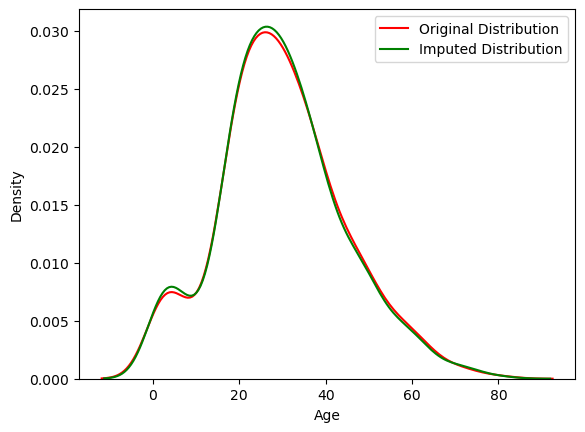

In [11]:
sns.kdeplot(x = X_train['Age'],color="red", label='Original Distribution')
sns.kdeplot(x = X_train['Age_imputed'],color="green", label='Imputed Distribution')
pyplot.legend()
pyplot.show()           # we can observe that distribution remains almost intact/same.

In [12]:
print("Original Age variance :", X_train['Age'].var())
print("Age variance after Imputation:", X_train['Age_imputed'].var())    # no such major change in variance

Original Age variance : 210.45286924636747
Age variance after Imputation: 208.9591787342649


In [13]:
X_train[['Age','Age_imputed','Fare']].cov()     # covv with other column changes

,Age,Age_imputed,Fare
Age,210.452869,210.452869,88.495367
Age_imputed,210.452869,208.959179,73.956025
Fare,88.495367,73.956025,2378.850837


<Axes: >

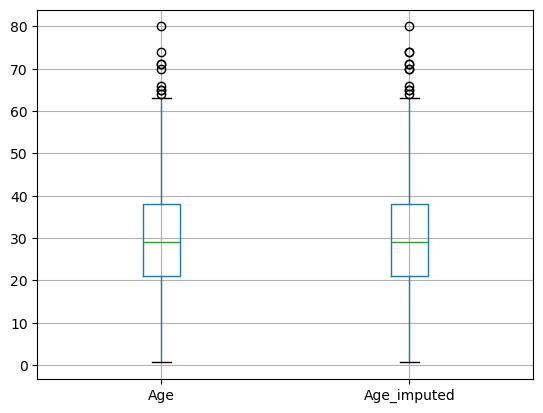

In [14]:
# No major change in outliers 
X_train[['Age', 'Age_imputed']].boxplot()

In [15]:
# Same Fare → same Age value picked every time
# Different Fare → different Age value picked

fare_value = df.loc[1, 'Fare']        # get single Fare value for 1st row
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(fare_value))

<h2 style="color:red">Random Imputation in Categorical Data</h2>

In [16]:
data = pd.read_csv('train.csv', usecols=['FireplaceQu','GarageQual','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [17]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [18]:
# Train test split 
X = data 
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape

((1095, 3), (365, 3))

In [19]:
X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

In [20]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,FireplaceQu_imputed,GarageQual_imputed
1223,NaN,TA,137900,NaN,TA
1371,TA,TA,165500,TA,TA
1021,NaN,TA,194000,NaN,TA
207,Po,TA,141000,Po,TA
709,NaN,TA,109900,NaN,TA


In [21]:
mask = X_train['GarageQual_imputed'].isnull()
X_train.loc[mask, 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state=42).values
mask = X_test['GarageQual_imputed'].isnull()
X_test.loc[mask, 'GarageQual_imputed'] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum(), random_state=42).values


mask_fp = X_train['FireplaceQu_imputed'].isnull()
X_train.loc[mask_fp, 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum(), random_state=42).values
mask_fp = X_test['FireplaceQu_imputed'].isnull()
X_test.loc[mask_fp, 'FireplaceQu_imputed'] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum(), random_state=42).values

In [22]:
X_train.sample(10)

,FireplaceQu,GarageQual,SalePrice,FireplaceQu_imputed,GarageQual_imputed
170,NaN,TA,128500,Fa,TA
191,NaN,TA,184000,Ex,TA
630,NaN,Fa,124000,Gd,Fa
708,Gd,TA,179540,Gd,TA
1434,Gd,TA,160000,Gd,TA
698,Gd,TA,138500,Gd,TA
45,Gd,TA,319900,Gd,TA
697,NaN,TA,123500,Gd,TA
1374,Gd,TA,250000,Gd,TA
879,NaN,TA,136500,TA,TA


In [25]:
# checking the frequency of each categorical column before and after imputation 

temp = pd.concat([
                X_train['GarageQual'].value_counts() / len(X_train), 
                X_train['GarageQual_imputed'].value_counts() / len(X_train) 
              ], axis=1
           )
temp.columns = ['original', 'imputed']
temp

# for 'GarageQual' column, no major frequency change is observed, so we can apply Random imputation.

,original,imputed
TA,0.900457,0.953425
Fa,0.031963,0.031963
Gd,0.010959,0.010959
Ex,0.002740,0.002740
Po,0.000913,0.000913


In [26]:
# checking the frequency of each categorical column before and after imputation 

temp2 = pd.concat([
                X_train['FireplaceQu'].value_counts() / len(X_train), 
                X_train['FireplaceQu_imputed'].value_counts() / len(X_train) 
              ], axis=1
           )
temp2.columns = ['original', 'imputed']
temp2

# for 'FireplaceQu' column, the frequency change is quite observable, so Random imputation is not advisable.

,original,imputed
Gd,0.261187,0.489498
TA,0.215525,0.407306
Fa,0.023744,0.044749
Ex,0.017352,0.031963
Po,0.014612,0.026484


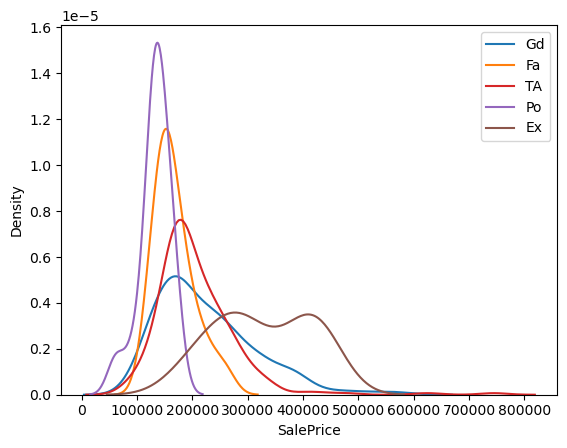

In [33]:
# distribution of SalePrice for each category of FireplaceQu using KDE plots, 
# enabling comparison of price behavior across different fireplace quality levels.
for category in X_train['FireplaceQu'].unique():
    mask = X_train['FireplaceQu'] == category
    sns.kdeplot(x = X_train.loc[mask, 'SalePrice'] , label = category)

pyplot.legend()
pyplot.show()

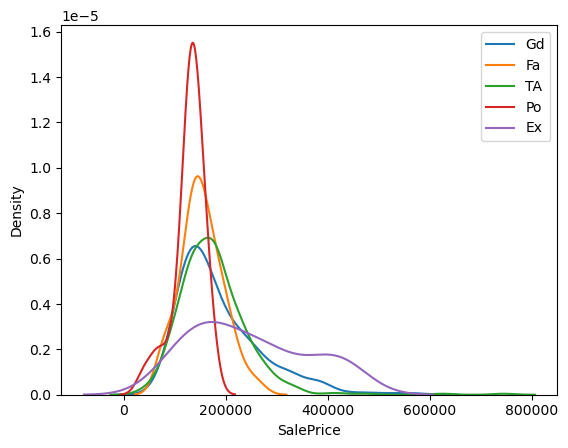

In [34]:
for category in X_train['FireplaceQu_imputed'].unique():
    mask = X_train['FireplaceQu_imputed'] == category
    sns.kdeplot(x = X_train.loc[mask, 'SalePrice'] , label = category)

pyplot.legend()
pyplot.show()

In [35]:
# if you are using a linear model, it's not preferable to apply Random Imputation on 'FireplaceQu', 
# bcz there's a lot of data is missing